### 1. Define the Problem

ทำนายเวลา Qualifying ต่ำสุดจาก Q1/Q2/Q3 ด้วย **เวลาซ้อม + ชนิดยาง + อายุยางของ FP1–FP3** รวม 9 features

หนึ่งแถว = นักขับหนึ่งคนในหนึ่งรายการแข่ง ชื่อคน/ทีม/สนามใช้เชื่อมข้อมูลเท่านั้น ไม่เข้าโมเดล และไม่ใช้ weather

เริ่มเก็บข้อมูลปี **2021–2023** ใหม่ ใช้ cache เดิมได้ แต่ไม่อ่าน CSV หรือโมเดลจากงานเก่า

### 2. Data Preparation

#### 2.1 ตั้งค่า library ปี และโฟลเดอร์
CSV ใหม่อยู่ใน `data/final/raw` ส่วนข้อมูล clean และโมเดลแยกโฟลเดอร์ ใช้ `f1_cache` เดิมเพื่อลดการดาวน์โหลดซ้ำ

In [1]:
from pathlib import Path
import json
import hashlib
import time

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

ROOT = Path.cwd().resolve()
if (ROOT / "f1_project").is_dir():
    ROOT = ROOT / "f1_project"

YEARS = [2021, 2022, 2023]
CACHE = ROOT / "f1_cache"
RAW = ROOT / "data/final/raw"
PROCESSED = ROOT / "data/final/processed"
MODELS = ROOT / "data/final/models"

for folder in [CACHE, RAW, PROCESSED, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE))
print("FastF1:", fastf1.__version__)
print("ปี:", YEARS)
for folder in [CACHE, RAW, PROCESSED, MODELS]:
    print(folder)

FastF1: 3.8.3
ปี: [2021, 2022, 2023]
/workspace/f1_project/f1_cache
/workspace/f1_project/data/final/raw
/workspace/f1_project/data/final/processed
/workspace/f1_project/data/final/models


#### 2.2 โหลดรายการแข่งทุกปี บันทึก `raw/events.csv`
ไม่รวม pre-season testing ตารางนี้ใช้วนโหลด FP1–FP3 และ Qualifying ของแต่ละรายการ

In [2]:
schedules = []
for year in YEARS:
    schedule = fastf1.get_event_schedule(year, include_testing=False, backend="fastf1")
    if schedule.empty:
        raise ValueError(f"ไม่มีตารางปี {year}")
    table = pd.DataFrame(schedule).copy()
    table.insert(0, "Year", year)
    schedules.append(table)
    print(year, len(table), "รายการ")

events = pd.concat(schedules, ignore_index=True)
events["event_id"] = events.Year.astype(str) + "-" + events.RoundNumber.astype(int).astype(str).str.zfill(2)
events.to_csv(RAW / "events.csv", index=False)
display(events[["event_id", "EventName", "EventFormat"]].head())

2021 22 รายการ
2022 22 รายการ
2023 22 รายการ


,event_id,EventName,EventFormat
0,2021-01,Bahrain Grand Prix,conventional
1,2021-02,Emilia Romagna Grand Prix,conventional
2,2021-03,Portuguese Grand Prix,conventional
3,2021-04,Spanish Grand Prix,conventional
4,2021-05,Monaco Grand Prix,conventional


#### 2.3 เตรียมคำสั่งโหลดหนึ่งรายการ
โหลด Practice ทุก lap และผล Qualifying เก็บทุกคอลัมน์ที่ FastF1 ส่งมาโดยยังไม่ clean เวลา timedelta ยังเป็นข้อความใน CSV

เก็บเวลาเริ่ม/จบ session เพิ่ม เพื่อกัน Practice ที่เกิดหลัง Qualifying ออกจาก input ในขั้น 2.7

In [3]:
SESSION_NAMES = {"Practice 1": "FP1", "Practice 2": "FP2", "Practice 3": "FP3", "Qualifying": "Q"}

def utc_time(info, field):
    timestamp = pd.Timestamp(info[field])
    if pd.isna(timestamp):
        raise ValueError(f"ไม่มี {field} ของ session")
    if timestamp.tzinfo is None:
        timestamp = (timestamp - pd.Timedelta(info["GmtOffset"])).tz_localize("UTC")
    return timestamp.tz_convert("UTC").isoformat()

def load_event(event):
    practice, metadata, qualifying = [], [], None
    for slot in range(1, 6):
        name = SESSION_NAMES.get(event[f"Session{slot}"])
        if name is None:
            continue
        # FP3 Russia 2021 ถูกยกเลิกเพราะฝน: ไม่สร้าง lap ใน raw
        if (int(event.Year), int(event.RoundNumber), name) == (2021, 15, "FP3"):
            metadata.append({"event_id": event.event_id, "Session": name,
                             "start_utc": None, "end_utc": None,
                             "status": "cancelled", "reason": "Heavy rain",
                             "source_path": "https://www.fia.com/news/f1-norris-takes-first-f1-pole-position-russia-ahead-sainz-and-russell"})
            print("FP3 ยกเลิกเพราะฝน: เก็บเป็น missing ไม่มี lap ทดแทนใน raw")
            continue
        session = fastf1.get_session(int(event.Year), int(event.RoundNumber), name)
        session.load(laps=True, telemetry=False, weather=False, messages=True)
        info = session.session_info
        metadata.append({"event_id": event.event_id, "Session": name,
                         "start_utc": utc_time(info, "StartDate"),
                         "end_utc": utc_time(info, "EndDate"),
                         "source_path": session.api_path})
        if name == "Q":
            qualifying = pd.DataFrame(session.results).copy()
            if qualifying.empty:
                raise ValueError("ไม่มีผล Qualifying")
            qualifying.insert(0, "event_id", event.event_id)
        else:
            laps = pd.DataFrame(session.laps).copy()
            if laps.empty:
                raise ValueError(f"{name} ไม่มี lap ต้องตรวจว่า session ยกเลิกหรือโหลดไม่สำเร็จ")
            laps.insert(0, "Session", name)
            laps.insert(0, "event_id", event.event_id)
            practice.append(laps)
    if not practice or qualifying is None:
        raise ValueError("ไม่มี Practice หรือ Qualifying")
    return pd.concat(practice, ignore_index=True), qualifying, pd.DataFrame(metadata)

def csv_hashes(folder):
    return {path.name: hashlib.sha256(path.read_bytes()).hexdigest()
            for path in sorted(folder.glob("*.csv"))}

#### 2.4 โหลดทุกปี บันทึก raw แยกรายการใน `raw/events/`
โหลดตามลำดับและแสดงความคืบหน้า รายการที่บันทึกครบแล้วจะข้ามเมื่อรันซ้ำ ถ้ามีรายการโหลดไม่สำเร็จให้ส่งตาราง `failed` มาตรวจก่อน ไม่ถือว่าข้อมูลหายคือศูนย์

Raw คือข้อมูลก่อน cleaning ของเรา แต่ FastF1 มีการประมวลผลข้อมูลจากระบบจับเวลามาแล้ว

In [4]:
failed = []
for position, (_, event) in enumerate(events.iterrows(), start=1):
    folder = RAW / "events" / event.event_id
    folder.mkdir(parents=True, exist_ok=True)
    marker = folder / "complete.json"
    files = ["practice_laps.csv", "qualifying_results.csv", "sessions.csv"]
    if marker.exists() and all((folder / name).exists() for name in files):
        if json.loads(marker.read_text()) == csv_hashes(folder):
            print(f"[{position}/{len(events)}] {event.event_id} มี CSV ครบแล้ว")
            continue
    print(f"[{position}/{len(events)}] {event.event_id} {event.EventName}", flush=True)
    try:
        tables = load_event(event)
        for table, name in zip(tables, files):
            table.to_csv(folder / name, index=False)
        marker.write_text(json.dumps(csv_hashes(folder)), encoding="utf-8")
        print("บันทึกแล้ว:", len(tables[0]), "practice laps", flush=True)
    except Exception as error:
        failed.append({"event_id": event.event_id, "error": str(error)})
        print("ไม่สำเร็จ:", str(error), flush=True)
    time.sleep(1)

failed = pd.DataFrame(failed, columns=["event_id", "error"])
failed.to_csv(PROCESSED / "download_failures.csv", index=False)
display(failed)
print("รายการที่ต้องตรวจ:", len(failed))

[1/66] 2021-01 มี CSV ครบแล้ว
[2/66] 2021-02 มี CSV ครบแล้ว
[3/66] 2021-03 มี CSV ครบแล้ว
[4/66] 2021-04 มี CSV ครบแล้ว
[5/66] 2021-05 มี CSV ครบแล้ว
[6/66] 2021-06 มี CSV ครบแล้ว
[7/66] 2021-07 มี CSV ครบแล้ว
[8/66] 2021-08 มี CSV ครบแล้ว
[9/66] 2021-09 มี CSV ครบแล้ว
[10/66] 2021-10 มี CSV ครบแล้ว
[11/66] 2021-11 มี CSV ครบแล้ว
[12/66] 2021-12 มี CSV ครบแล้ว
[13/66] 2021-13 มี CSV ครบแล้ว
[14/66] 2021-14 มี CSV ครบแล้ว
[15/66] 2021-15 มี CSV ครบแล้ว
[16/66] 2021-16 มี CSV ครบแล้ว
[17/66] 2021-17 มี CSV ครบแล้ว
[18/66] 2021-18 มี CSV ครบแล้ว
[19/66] 2021-19 มี CSV ครบแล้ว
[20/66] 2021-20 มี CSV ครบแล้ว
[21/66] 2021-21 มี CSV ครบแล้ว
[22/66] 2021-22 มี CSV ครบแล้ว
[23/66] 2022-01 มี CSV ครบแล้ว
[24/66] 2022-02 มี CSV ครบแล้ว
[25/66] 2022-03 มี CSV ครบแล้ว
[26/66] 2022-04 มี CSV ครบแล้ว
[27/66] 2022-05 มี CSV ครบแล้ว
[28/66] 2022-06 มี CSV ครบแล้ว
[29/66] 2022-07 มี CSV ครบแล้ว
[30/66] 2022-08 มี CSV ครบแล้ว
[31/66] 2022-09 มี CSV ครบแล้ว
[32/66] 2022-10 มี CSV ครบแล้ว
[33/66] 2022-11 ม

,event_id,error


รายการที่ต้องตรวจ: 0


#### 2.5 รวมไฟล์เป็น `practice_laps.csv`, `qualifying_results.csv` และ `sessions.csv`
หยุดขั้นนี้ถ้ามีรายการโหลดไม่ครบ ไม่ใช้ dataset เก่ามาเติมแทน เลข `source_row` ที่จะเพิ่มตอน clean อ้างถึงแถวใน CSV รวม

In [5]:
assert failed.empty, "มีรายการโหลดไม่ครบ: ตรวจ download_failures.csv ก่อนรวมข้อมูล"

for name in ["practice_laps.csv", "qualifying_results.csv", "sessions.csv"]:
    parts = [pd.read_csv(RAW / "events" / event_id / name, low_memory=False)
             for event_id in events.event_id]
    combined = pd.concat(parts, ignore_index=True)
    combined.to_csv(RAW / name, index=False)
    print(name, len(combined), "แถว")

laps = pd.read_csv(RAW / "practice_laps.csv", low_memory=False)
results = pd.read_csv(RAW / "qualifying_results.csv", low_memory=False)
sessions = pd.read_csv(RAW / "sessions.csv")
raw_checksums = csv_hashes(RAW)
display(laps[["event_id", "Session", "Driver", "LapTime", "Compound", "TyreLife"]].head())

practice_laps.csv 79661 แถว
qualifying_results.csv 1320 แถว
sessions.csv 246 แถว


,event_id,Session,Driver,LapTime,Compound,TyreLife
0,2021-01,FP1,RIC,NaN,HARD,1.0
1,2021-01,FP1,RIC,0 days 00:01:34.212000,HARD,2.0
2,2021-01,FP1,RIC,0 days 00:02:11.716000,HARD,3.0
3,2021-01,FP1,RIC,0 days 00:01:34.523000,HARD,4.0
4,2021-01,FP1,RIC,0 days 00:02:10.037000,HARD,5.0


#### 2.6 ตรวจ missing / duplicate และ clean lap
แปลงเวลาเป็นวินาที ตัดแถวซ้ำ ไม่มีเวลา/นักขับ เวลาไม่บวก ถูกลบเวลา ไม่แม่นยำ และแถวที่ FastF1 สร้าง เก็บเหตุผลแรกต่อแถวให้ยอดก่อน–หลังตรวจสอบได้ ยังไม่ตัดแถวที่ข้อมูลยางขาด

In [6]:
display(laps.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("แถวซ้ำ:", laps.duplicated().sum())

audit = laps.copy()
duplicates = audit.duplicated()
audit["source_row"] = np.arange(len(audit)) + 2
audit["LapTime"] = pd.to_timedelta(audit.LapTime, errors="coerce").dt.total_seconds()

def is_true(series):
    return series.astype("string").str.lower().isin(["true", "1"])

rules = {
    "duplicate": duplicates,
    "missing_time_or_driver": audit.LapTime.isna() | audit.Driver.isna(),
    "nonpositive_time": audit.LapTime.le(0),
    "deleted": is_true(audit.Deleted),
    "inaccurate": audit.IsAccurate.notna() & ~is_true(audit.IsAccurate),
    "generated": is_true(audit.FastF1Generated),
}
audit["reason"] = "kept"
remaining, cleaning_report = len(audit), []
for reason, mask in rules.items():
    audit[f"flag_{reason}"] = mask
    removed = audit.reason.eq("kept") & mask
    audit.loc[removed, "reason"] = reason
    count = int(removed.sum())
    cleaning_report.append({"rule": reason, "before": remaining, "removed": count, "after": remaining - count})
    remaining -= count

display(pd.DataFrame(cleaning_report))
assert remaining == audit.reason.eq("kept").sum()

,missing
LapStartDate,79661
Position,79661
DeletedReason,79052
PitInTime,65374
PitOutTime,65284
LapTime,14734
SpeedFL,14289
Sector1SessionTime,9543
Sector1Time,9476
Sector3SessionTime,2665


แถวซ้ำ: 0


,rule,before,removed,after
0,duplicate,79661,0,79661
1,missing_time_or_driver,79661,14734,64927
2,nonpositive_time,64927,0,64927
3,deleted,64927,609,64318
4,inaccurate,64318,13902,50416
5,generated,50416,0,50416


#### 2.7 ใช้เฉพาะ Practice ที่จบก่อน Qualifying
ใช้ metadata ของ session จริง ไม่เดาว่า FP2/FP3 ต้องอยู่ก่อน Q เสมอ แล้วบันทึก audit และข้อมูล clean แยกจาก raw

In [7]:
for column in ["start_utc", "end_utc"]:
    sessions[column] = pd.to_datetime(sessions[column], utc=True)
q_start = sessions.loc[sessions.Session.eq("Q")].set_index("event_id").start_utc
sessions["before_q"] = sessions.end_utc.lt(sessions.event_id.map(q_start))
audit = audit.merge(sessions[["event_id", "Session", "before_q"]],
                    on=["event_id", "Session"], how="left", validate="many_to_one")
audit["before_q"] = audit.before_q.eq(True)
after_q = audit.reason.eq("kept") & ~audit.before_q
audit.loc[after_q, "reason"] = "not_before_qualifying"
clean = audit.loc[audit.reason.eq("kept")].copy()

audit.to_csv(PROCESSED / "lap_audit.csv", index=False)
clean.to_csv(PROCESSED / "practice_clean.csv", index=False)
print("ตัดเพราะไม่ยืนยันว่าก่อน Q:", int(after_q.sum()))
print("เหลือ:", len(clean), "จาก", len(laps), "แถว")
display(audit.reason.value_counts().to_frame("rows"))

ตัดเพราะไม่ยืนยันว่าก่อน Q: 2662
เหลือ: 47754 จาก 79661 แถว


,rows
reason,
kept,47754
missing_time_or_driver,14734
inaccurate,13902
not_before_qualifying,2662
deleted,609


#### 2.8 เลือก lap เร็วที่สุด แล้วจับคู่กับเวลา Qualifying
เวลา ชนิดยาง และอายุยางใช้จาก **lap เดียวกัน** หากเวลาเท่ากันเลือก source row ที่มาก่อน Target คือเวลาบวกต่ำสุดของ Q1/Q2/Q3

In [8]:
PRACTICES = ["FP1", "FP2", "FP3"]
TIMES = [f"{s}_Time" for s in PRACTICES]
AGES = [f"{s}_TyreLife" for s in PRACTICES]
COMPOUNDS = [f"{s}_Compound" for s in PRACTICES]
FEATURES = [f"{s}_{field}" for s in PRACTICES for field in ["Time", "Compound", "TyreLife"]]

best = clean.sort_values(["LapTime", "source_row"], kind="stable").drop_duplicates(
    ["event_id", "Driver", "Session"]
)
display(best[["source_row", "event_id", "Driver", "Session", "LapTime", "Compound", "TyreLife"]].head())

target = results.rename(columns={"Abbreviation": "Driver"}).copy()
print("ผล Qualifying ซ้ำ:", target.duplicated(["event_id", "Driver"]).sum())
target = target.drop_duplicates(["event_id", "Driver"])
for column in ["Q1", "Q2", "Q3"]:
    seconds = pd.to_timedelta(target[column], errors="coerce").dt.total_seconds()
    target[column] = seconds.where(seconds.gt(0))
target["QualiTime"] = target[["Q1", "Q2", "Q3"]].min(axis=1)
features = target[["event_id", "Driver", "QualiTime"]].merge(
    events[["event_id", "Year", "EventName"]], on="event_id", validate="many_to_one"
)

for session_name in PRACTICES:
    columns = {"LapTime": "Time", "Compound": "Compound", "TyreLife": "TyreLife", "source_row": "source_row"}
    selected = best.loc[best.Session.eq(session_name), ["event_id", "Driver", *columns]]
    selected = selected.rename(columns={c: f"{session_name}_{suffix}" for c, suffix in columns.items()})
    features = features.merge(selected, on=["event_id", "Driver"], how="left", validate="one_to_one")

features.to_csv(PROCESSED / "features_before_fill.csv", index=False)
display(features[["event_id", "Driver", *FEATURES, "QualiTime"]].head())

,source_row,event_id,Driver,Session,LapTime,Compound,TyreLife
11059,11061,2021-08,HAM,FP3,64.369,SOFT,2.0
12318,12320,2021-09,HAM,FP2,64.523,SOFT,2.0
11043,11045,2021-08,VER,FP3,64.573,SOFT,2.0
12828,12830,2021-09,VER,FP3,64.591,SOFT,2.0
12455,12457,2021-09,BOT,FP2,64.712,SOFT,2.0


ผล Qualifying ซ้ำ: 0


,event_id,Driver,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife,QualiTime
0,2021-01,VER,91.394,SOFT,2.0,90.847,SOFT,2.0,90.577,SOFT,2.0,88.997
1,2021-01,HAM,91.921,SOFT,2.0,91.082,SOFT,2.0,91.316,SOFT,2.0,89.385
2,2021-01,BOT,91.692,SOFT,2.0,91.218,SOFT,2.0,91.855,SOFT,2.0,89.586
3,2021-01,LEC,91.993,SOFT,2.0,91.612,SOFT,2.0,92.482,MEDIUM,2.0,89.678
4,2021-01,GAS,92.195,SOFT,2.0,91.483,SOFT,2.0,91.583,SOFT,2.0,89.809


#### 2.9 จัดการข้อมูลที่ขาด
ไม่มี target ไม่นำไปฝึก; ไม่มี Practice เลยไม่ทำนาย ถ้าขาดบาง session ใช้ทั้งเวลาและยางจาก session ที่เร็วที่สุดในแถวนั้น ข้อมูลยางไม่ทราบเป็น UNKNOWN ส่วนอายุยางจะเติมด้วย training median ในขั้น 3.2

In [9]:
print("ไม่มี target:", features.QualiTime.isna().sum())
print("ไม่มี Practice เลย:", features[TIMES].isna().all(axis=1).sum())
dataset = features.loc[features.QualiTime.notna() & features[TIMES].notna().any(axis=1)].copy()

def fill_sessions(frame):
    filled = frame.copy()
    filled[COMPOUNDS] = filled[COMPOUNDS].astype(object)
    filled[AGES] = filled[AGES].apply(pd.to_numeric, errors="coerce").astype(float)
    source = filled.copy()
    if filled[TIMES].isna().all(axis=1).any():
        raise ValueError("ต้องมี Practice อย่างน้อยหนึ่ง session")
    fastest = filled[TIMES].idxmin(axis=1).str.replace("_Time", "", regex=False)
    for session_name in PRACTICES:
        missing = filled[f"{session_name}_Time"].isna()
        filled[f"{session_name}_filled_from"] = session_name
        for donor in PRACTICES:
            mask = missing & fastest.eq(donor)
            for field in ["Time", "Compound", "TyreLife"]:
                filled.loc[mask, f"{session_name}_{field}"] = source.loc[mask, f"{donor}_{field}"]
            filled.loc[mask, f"{session_name}_filled_from"] = donor
    filled[COMPOUNDS] = filled[COMPOUNDS].fillna("UNKNOWN").replace({"TEST_UNKNOWN": "UNKNOWN", "": "UNKNOWN"})
    filled[AGES] = filled[AGES].where(np.isfinite(filled[AGES]) & filled[AGES].ge(0))
    return filled

dataset = fill_sessions(dataset)
dataset.to_csv(PROCESSED / "model_dataset.csv", index=False)
display(dataset[["event_id", "Driver", *[f"{s}_filled_from" for s in PRACTICES]]].head())
print("ใช้ฝึก/ประเมิน:", len(dataset), "แถว")

ไม่มี target: 16
ไม่มี Practice เลย: 5


,event_id,Driver,FP1_filled_from,FP2_filled_from,FP3_filled_from
0,2021-01,VER,FP1,FP2,FP3
1,2021-01,HAM,FP1,FP2,FP3
2,2021-01,BOT,FP1,FP2,FP3
3,2021-01,LEC,FP1,FP2,FP3
4,2021-01,GAS,FP1,FP2,FP3


ใช้ฝึก/ประเมิน: 1299 แถว


### 3. Model Development

#### 3.1 แบ่งตามปี
2021 ฝึก, 2022 เลือกโมเดล, 2023 ประเมินย้อนหลัง (เคยใช้ปีนี้วิเคราะห์ปัญหาแล้ว) แถวของ event เดียวกันไม่ข้ามชุด และ X มีเพียง 9 features เวลา+ยาง

In [10]:
train = dataset.loc[dataset.Year.eq(2021)].copy()
validation = dataset.loc[dataset.Year.eq(2022)].copy()
test = dataset.loc[dataset.Year.eq(2023)].copy()
assert all(len(part) > 0 for part in [train, validation, test]), "ข้อมูลบางชุดว่าง"

X_train, y_train = train[FEATURES].copy(), train.QualiTime
X_valid, y_valid = validation[FEATURES].copy(), validation.QualiTime
X_test, y_test = test[FEATURES].copy(), test.QualiTime

display(pd.DataFrame({"split": ["Train", "Validation", "Test"],
                      "rows": [len(train), len(validation), len(test)]}))
print("X:", FEATURES)
print("y: QualiTime")
assert len(FEATURES) == 9
assert not set(train.event_id) & set(validation.event_id)
assert not set(train.event_id) & set(test.event_id)

,split,rows
0,Train,432
1,Validation,436
2,Test,431


X: ['FP1_Time', 'FP1_Compound', 'FP1_TyreLife', 'FP2_Time', 'FP2_Compound', 'FP2_TyreLife', 'FP3_Time', 'FP3_Compound', 'FP3_TyreLife']
y: QualiTime


#### 3.2 เติมอายุยางด้วย median ของ Train
ถ้าคอลัมน์อายุยางว่างทั้งชุด ใช้ median รวมของอายุยาง Practice ใน Train ไม่คำนวณจาก Validation/Test

In [11]:
age_medians = X_train[AGES].median().fillna(X_train[AGES].stack().median())
assert age_medians.notna().all(), "ไม่มีอายุยางที่ใช้ได้ใน Train ต้องตรวจข้อมูลก่อน"

display(X_train[AGES].isna().sum().to_frame("missing before"))
display(age_medians.to_frame("train median"))
X_train = X_train.fillna(age_medians)
X_valid = X_valid.fillna(age_medians)
X_test = X_test.fillna(age_medians)
display(X_train[AGES].head())

,missing before
FP1_TyreLife,19
FP2_TyreLife,0
FP3_TyreLife,0


,train median
FP1_TyreLife,4.0
FP2_TyreLife,3.0
FP3_TyreLife,3.0


,FP1_TyreLife,FP2_TyreLife,FP3_TyreLife
0,2.0,2.0,2.0
1,2.0,2.0,2.0
2,2.0,2.0,2.0
3,2.0,2.0,2.0
4,2.0,2.0,2.0


#### 3.3 One-hot ชนิดยาง และ StandardScaler ตัวเลข
fit เฉพาะ Train ชนิดยางเก่าอย่าง SUPERSOFT/ULTRASOFT/HYPERSOFT เก็บชื่อจริง ไม่แปลงเป็น SOFT เอง

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), TIMES + AGES),
    ("compound", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COMPOUNDS),
])
preview = clone(preprocessor)
matrix = preview.fit_transform(X_train)
display(pd.DataFrame(matrix, columns=preview.get_feature_names_out()).head())

,numeric__FP1_Time,numeric__FP2_Time,numeric__FP3_Time,numeric__FP1_TyreLife,numeric__FP2_TyreLife,numeric__FP3_TyreLife,compound__FP1_Compound_HARD,compound__FP1_Compound_MEDIUM,compound__FP1_Compound_SOFT,compound__FP1_Compound_UNKNOWN,compound__FP2_Compound_HARD,compound__FP2_Compound_MEDIUM,compound__FP2_Compound_SOFT,compound__FP3_Compound_HARD,compound__FP3_Compound_INTERMEDIATE,compound__FP3_Compound_MEDIUM,compound__FP3_Compound_SOFT
0,0.636460,0.665421,0.485783,-0.851089,-0.772483,-0.811471,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.683952,0.687034,0.543321,-0.851089,-0.772483,-0.811471,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.663315,0.699542,0.585287,-0.851089,-0.772483,-0.811471,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.690440,0.735779,0.634104,-0.851089,-0.772483,-0.811471,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.708644,0.723914,0.564109,-0.851089,-0.772483,-0.811471,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


#### 3.4 เปรียบเทียบ Regression 4 โมเดล
Linear Regression: ความสัมพันธ์เชิงเส้น · Random Forest: เฉลี่ยจากหลายต้นไม้ · Gradient Boosting: เพิ่มต้นไม้เพื่อแก้ความผิดพลาด · SVR (RBF): เรียนรู้ความสัมพันธ์แบบไม่เป็นเส้นตรง
ใช้ features และชุดแบ่งข้อมูลเดียวกันทุกโมเดล ค่าพารามิเตอร์เป็นจุดเริ่มต้น ยังไม่ได้ทำ tuning และไม่มีโมเดลใดรับประกันว่าจะดีที่สุด
เลือกอัลกอริทึมด้วย Validation RMSE ต่ำสุด ไม่ใช้คะแนนปี 2023 เลือกโมเดล

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

def scores(actual, predicted):
    return {"MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted))}

candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
}
candidates.update({
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=2,
        min_samples_leaf=3, random_state=42
    ),
    "SVR (RBF)": SVR(kernel="rbf", C=100, epsilon=0.1),
})
validation_scores = []
for name, estimator in candidates.items():
    model = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    model.fit(X_train, y_train)
    predicted = model.predict(X_valid)
    validation_scores.append({"Model": name, **scores(y_valid, predicted)})

validation_scores = pd.DataFrame(validation_scores).sort_values("RMSE")
display(validation_scores)
chosen = validation_scores.iloc[0]["Model"]
print("เลือก:", chosen)

,Model,MAE,RMSE
3,SVR (RBF),2.736839,4.952356
0,Linear Regression,3.336418,5.374857
2,Gradient Boosting,3.062648,5.972580
1,Random Forest,3.584396,6.794922


เลือก: SVR (RBF)


#### 3.5 ปรับพารามิเตอร์ (Hyperparameter Tuning)
ลองชุดค่าด้วย ParameterGrid: fit_intercept ควบคุมจุดตัดแกน, max_depth ความลึกต้นไม้, min_samples_leaf จำนวนตัวอย่างขั้นต่ำในใบ, learning_rate ขนาดการเรียนรู้ของ Boosting ส่วน SVR ใช้ C ควบคุมโทษความผิดพลาด, epsilon ระยะคลาดเคลื่อนที่ยอมรับ และ gamma ความเฉพาะจุดของความสัมพันธ์
ทุกชุดฝึกด้วยปี 2021 และวัดปี 2022 เท่านั้น preprocessing ยัง fit เฉพาะปี 2021 ไม่ใช้ปี 2023 เลือกค่า คะแนน validation หลัง tuning ใช้เลือกโมเดล ไม่ใช่ผลประเมินอิสระ และไม่รับประกันว่าจะดีขึ้นในปีอื่น

In [14]:
from sklearn.model_selection import ParameterGrid

param_grids = {
    "Linear Regression": {"fit_intercept": [True, False]},
    "Random Forest": {"max_depth": [None, 10], "min_samples_leaf": [1, 3]},
    "Gradient Boosting": {"learning_rate": [0.03, 0.05], "max_depth": [2, 3]},
    "SVR (RBF)": {"C": [10, 100], "epsilon": [0.1, 0.5], "gamma": ["scale", 0.01]},
}
display(pd.DataFrame([{"Model": name, "ค่าที่ลอง": str(grid)}
                      for name, grid in param_grids.items()]))

trials, tuned_estimators = [], {}
for name, estimator in candidates.items():
    best_rmse = float("inf")
    # รวมค่าเดิมไว้ด้วย เพื่อไม่บังคับใช้ค่าที่แย่ลงบน validation
    for params in [{}] + list(ParameterGrid(param_grids[name])):
        candidate = clone(estimator).set_params(**params)
        pipeline = Pipeline([("preprocess", clone(preprocessor)), ("model", candidate)])
        pipeline.fit(X_train, y_train)
        metrics = scores(y_valid, pipeline.predict(X_valid))
        trials.append({"Model": name, "Parameters": params, **metrics})
        if metrics["RMSE"] < best_rmse:
            best_rmse = metrics["RMSE"]
            tuned_estimators[name] = clone(candidate)

tuning_results = pd.DataFrame(trials).sort_values("RMSE", kind="stable")
best_tuned = tuning_results.drop_duplicates("Model")
comparison = validation_scores.merge(best_tuned, on="Model", suffixes=("_before", "_after"))
display(comparison[["Model", "RMSE_before", "RMSE_after", "MAE_after", "Parameters"]])
tuning_results.to_csv(PROCESSED / "tuning_validation.csv", index=False)
chosen = best_tuned.iloc[0]["Model"]
print("เลือกหลังปรับพารามิเตอร์:", chosen)
print("พารามิเตอร์:", tuned_estimators[chosen].get_params())


,Model,ค่าที่ลอง
0,Linear Regression,"{'fit_intercept': [True, False]}"
1,Random Forest,"{'max_depth': [None, 10], 'min_samples_leaf': ..."
2,Gradient Boosting,"{'learning_rate': [0.03, 0.05], 'max_depth': [..."
3,SVR (RBF),"{'C': [10, 100], 'epsilon': [0.1, 0.5], 'gamma..."


,Model,RMSE_before,RMSE_after,MAE_after,Parameters
0,SVR (RBF),4.952356,4.932036,2.758883,"{'C': 100, 'epsilon': 0.5, 'gamma': 'scale'}"
1,Linear Regression,5.374857,5.374857,3.336418,{}
2,Gradient Boosting,5.972580,5.972580,3.062648,{}
3,Random Forest,6.794922,6.792742,3.582272,"{'max_depth': 10, 'min_samples_leaf': 3}"


เลือกหลังปรับพารามิเตอร์: SVR (RBF)
พารามิเตอร์: {'C': 100, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


#### 3.6 ฝึกโมเดลที่เลือกใหม่ด้วย Train + Validation
คำนวณ median และ fit preprocessing ใหม่จากปี 2021–2022 เท่านั้น ยังไม่ใช้ปี 2023

In [15]:
final_train = pd.concat([train, validation], ignore_index=True)
final_medians = final_train[AGES].median().fillna(final_train[AGES].stack().median())
final_X = final_train[FEATURES].fillna(final_medians)
final_model = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", clone(tuned_estimators[chosen])),
])
final_model.fit(final_X, final_train.QualiTime)
print("ฝึกเสร็จ:", chosen, len(final_train), "แถว")

ฝึกเสร็จ: SVR (RBF) 868 แถว


### 4. Model Evaluation

#### 4.1 วัด MAE / RMSE ย้อนหลังบนปี 2023
เทียบกับเวลา Practice ที่เร็วที่สุดเป็นค่าอ้างอิง คะแนนต่ำดีกว่า รายงานตามจริงไม่ว่าผลจะชนะหรือแพ้ baseline

In [16]:
test_prediction = final_model.predict(test[FEATURES].fillna(final_medians))
baseline = test[TIMES].min(axis=1)
evaluation = pd.DataFrame([
    {"Model": chosen, **scores(y_test, test_prediction)},
    {"Model": "Best practice baseline", **scores(y_test, baseline)},
])
display(evaluation)

test_results = test[["event_id", "EventName", "Driver", "QualiTime"]].copy()
test_results["Prediction"] = test_prediction
test_results["Error"] = test_results.Prediction - test_results.QualiTime
test_results.to_csv(PROCESSED / "test_predictions_2023.csv", index=False)
evaluation.to_csv(PROCESSED / "evaluation_2023.csv", index=False)
display(test_results.head())

,Model,MAE,RMSE
0,SVR (RBF),2.372987,4.957968
1,Best practice baseline,2.246914,4.433238


,event_id,EventName,Driver,QualiTime,Prediction,Error
880,2023-01,Bahrain Grand Prix,VER,89.708,90.725075,1.017075
881,2023-01,Bahrain Grand Prix,PER,89.846,90.613310,0.767310
882,2023-01,Bahrain Grand Prix,LEC,90.000,90.385491,0.385491
883,2023-01,Bahrain Grand Prix,SAI,90.154,91.179151,1.025151
884,2023-01,Bahrain Grand Prix,ALO,90.336,90.594546,0.258546


#### 4.2 ดูกราฟค่าจริงเทียบค่าทำนาย และ error รายสนาม
จุดใกล้เส้นทแยงหมายถึงทำนายใกล้จริง ค่า Error บวกหมายถึงทำนายช้ากว่าเวลาจริง

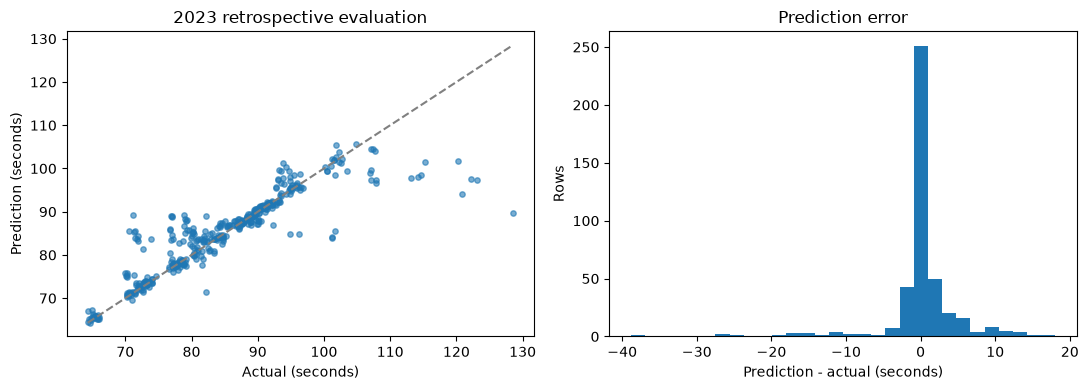

,event_id,Event,N,MAE,RMSE
0,2023-01,Bahrain Grand Prix,20,0.513663,0.641580
1,2023-02,Saudi Arabian Grand Prix,20,2.460247,8.734899
2,2023-03,Australian Grand Prix,19,0.697897,1.094950
3,2023-04,Azerbaijan Grand Prix,20,4.293131,7.397967
4,2023-05,Miami Grand Prix,20,0.438038,0.586394
5,2023-06,Monaco Grand Prix,20,1.339979,2.518614
6,2023-07,Spanish Grand Prix,20,0.457513,0.545102
7,2023-08,Canadian Grand Prix,20,2.997625,3.504969
8,2023-09,Austrian Grand Prix,20,0.649582,0.937228
9,2023-10,British Grand Prix,20,1.345988,1.869194


ตรวจแล้ว: raw CSV ไม่ถูกแก้ไข


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_prediction, s=15, alpha=.6)
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, "--", color="gray")
axes[0].set(xlabel="Actual (seconds)", ylabel="Prediction (seconds)", title="2023 retrospective evaluation")
axes[1].hist(test_results.Error, bins=30)
axes[1].set(xlabel="Prediction - actual (seconds)", ylabel="Rows", title="Prediction error")
plt.tight_layout()
plt.show()

per_event = pd.DataFrame([
    {"event_id": event_id, "Event": group.EventName.iloc[0], "N": len(group),
     **scores(group.QualiTime, group.Prediction)}
    for event_id, group in test_results.groupby("event_id")
])
display(per_event)
per_event.to_csv(PROCESSED / "evaluation_by_event.csv", index=False)
assert csv_hashes(RAW) == raw_checksums, "raw เปลี่ยนระหว่างเตรียมข้อมูล/ฝึก"
print("ตรวจแล้ว: raw CSV ไม่ถูกแก้ไข")

### 5. Deployment

#### 5.1 บันทึกโมเดลพร้อม preprocessing และ median
บันทึกโมเดลใหม่ที่ `data/final/models/qualifying.joblib` ยังไม่แทนโมเดลบนเว็บ

In [18]:
model_path = MODELS / "qualifying.joblib"
bundle = {
    "model": final_model,
    "age_medians": final_medians,
    "features": FEATURES,
    "numeric_min": final_X[TIMES + AGES].min(),
    "numeric_max": final_X[TIMES + AGES].max(),
    "years": YEARS,
    "raw_checksums": raw_checksums,
}
joblib.dump(bundle, model_path)
print(model_path)

/workspace/f1_project/data/final/models/qualifying.joblib


#### 5.2 โหลดโมเดลและกรอกเวลาซ้อมกับยาง
เวลาเป็นวินาที อายุยางเป็นจำนวนรอบ หากไม่มี session ใช้ `None` ทั้งสามช่อง ไม่มี Practice เลยจะไม่ทำนาย ต้องใช้ข้อมูลซ้อมก่อน Qualifying

In [20]:
loaded = joblib.load(model_path)
new_data = pd.DataFrame([{
    "FP1_Time": 93.0, "FP1_Compound": "SOFT", "FP1_TyreLife": 3,
    "FP2_Time": 91.0, "FP2_Compound": "SOFT", "FP2_TyreLife": 4,
    "FP3_Time": None, "FP3_Compound": None, "FP3_TyreLife": None,
}])

for column in TIMES + AGES:
    new_data[column] = pd.to_numeric(new_data[column], errors="raise")
assert not (new_data[TIMES].notna() & (~np.isfinite(new_data[TIMES]) | new_data[TIMES].le(0))).any().any(), "เวลาต้องเป็นตัวเลขบวก"
assert not (new_data[AGES].notna() & (~np.isfinite(new_data[AGES]) | new_data[AGES].lt(0))).any().any(), "อายุยางต้องไม่ติดลบ"

filled_input = fill_sessions(new_data)
display(filled_input)
new_X = filled_input[loaded["features"]].fillna(loaded["age_medians"])
display(new_X)
outside = (new_X[TIMES + AGES].lt(loaded["numeric_min"]) | new_X[TIMES + AGES].gt(loaded["numeric_max"])).any()
print("Input นอกช่วงฝึก:", outside[outside].index.tolist())
prediction = float(loaded["model"].predict(new_X)[0])
assert np.isfinite(prediction) and prediction > 0, "ผลทำนายอยู่นอกขอบเขตที่ใช้ได้"
print(f"เวลา Qualifying ที่ทำนาย: {prediction:.3f} วินาที")
np.testing.assert_allclose(
    loaded["model"].predict(test[FEATURES].fillna(loaded["age_medians"])),
    test_prediction,
)

,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife,FP1_filled_from,FP2_filled_from,FP3_filled_from
0,93.0,SOFT,3.0,91.0,SOFT,4.0,91.0,SOFT,4.0,FP1,FP2,FP2


,FP1_Time,FP1_Compound,FP1_TyreLife,FP2_Time,FP2_Compound,FP2_TyreLife,FP3_Time,FP3_Compound,FP3_TyreLife
0,93.0,SOFT,3.0,91.0,SOFT,4.0,91.0,SOFT,4.0


Input นอกช่วงฝึก: []
เวลา Qualifying ที่ทำนาย: 90.065 วินาที
